# Work Pressure, Recovery, and Sustainable Well-Being  
## A Survey-Driven Analysis of Young Professionals in Singapore

This notebook presents an end-to-end data science analysis exploring how work patterns, pressure, recovery, and boundaries relate to sustainable mental well-being among young professionals in Singapore.

The goal is not only to describe patterns, but to understand **mechanisms** and **practical implications** for social good and policy design.


## 1. Data Loading and Initial Inspection

We begin by loading the survey dataset and inspecting its basic structure.

The dataset contains simulated responses capturing:
- Work intensity and expectations
- Recovery and exhaustion
- Boundary control
- Perceived long-term sustainability of work life


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

FILE_PATH = "/content/Project 3 Survery Data - Project 3 Survey Data (1).csv"

df_raw = pd.read_csv(FILE_PATH)
print("Shape:", df_raw.shape)
df_raw.head()


Shape: (74, 18)


,Consent_18plus,Age_Group,Employment_Status,Industry,Weekly_Work_Hours,Commute_OneWay,Q7_Disconnect_AfterHours,Q8_AfterHours_Messages_Common,Q9_Workload_Manageable,Q10_AlwaysAvailable_Pressure,Q11_TimeOff_Respected,Sleep_WorkNights,Exhaustion_Frequency,Skipped_Plans_Frequency,Q15_Enough_Recovery_BetweenDays,Q16_LongHours_Rewarded,Q17_Comfort_Setting_Boundaries,Q18_Sustainable_LongTerm
0,Yes,23–26,Full-time,Technology,45–54,15–30,3,4,3,4,3,6–7 hours,Sometimes,Weekly,3,4,3,3
1,Yes,27–30,Full-time,Finance / Banking,55–64,31–45,2,5,2,5,2,5–6 hours,Often,Multiple times per week,2,5,2,2
2,Yes,23–26,Full-time,Consulting,65+,31–45,2,5,1,5,2,< 5 hours,Very often,Almost every day,2,5,2,1
3,Yes,31–35,Full-time,Government / Public Sector,35–44,15–30,4,2,4,2,4,7–8 hours,Rarely,1–2 times,4,2,4,4
4,Yes,27–30,Full-time,Healthcare,45–54,46–60,3,4,3,4,3,5–6 hours,Often,Weekly,3,4,3,3


## 2. Column Cleaning and Text Normalization

Survey datasets often contain inconsistent formatting (extra whitespace, different dash characters, line breaks).

To ensure robustness and reproducibility, we:
- Standardize column names
- Normalize textual responses
- Remove formatting artifacts that could break downstream analysis


In [2]:
df = df_raw.copy()

def clean_col(c):
    c = str(c).strip()
    c = c.replace("\n", " ")
    c = c.replace("–", "-").replace("—", "-")
    c = " ".join(c.split())
    return c

df.columns = [clean_col(c) for c in df.columns]

# Normalize dash characters inside string cells too
def norm_text(x):
    if pd.isna(x):
        return x
    x = str(x).strip()
    x = x.replace("–", "-").replace("—", "-")
    x = " ".join(x.split())
    return x

for c in df.columns:
    if df[c].dtype == "object":
        df[c] = df[c].apply(norm_text)

print("Columns:")
for c in df.columns:
    print("-", c)


Columns:
- Consent_18plus
- Age_Group
- Employment_Status
- Industry
- Weekly_Work_Hours
- Commute_OneWay
- Q7_Disconnect_AfterHours
- Q8_AfterHours_Messages_Common
- Q9_Workload_Manageable
- Q10_AlwaysAvailable_Pressure
- Q11_TimeOff_Respected
- Sleep_WorkNights
- Exhaustion_Frequency
- Skipped_Plans_Frequency
- Q15_Enough_Recovery_BetweenDays
- Q16_LongHours_Rewarded
- Q17_Comfort_Setting_Boundaries
- Q18_Sustainable_LongTerm


## 3. Data Quality and Distribution Checks

Before any modeling, we assess:
- Missingness across variables
- Distribution of key categorical fields (industry, hours, commute, sleep)

This step ensures the dataset has sufficient variation and avoids modeling artifacts.


In [3]:
missing = df.isna().mean().sort_values(ascending=False)
missing[missing > 0]


,0


In [4]:
# Peek categorical distributions (adjust list if your column names differ)
cat_cols = ["Age_Group", "Employment_Status", "Industry", "Weekly_Work_Hours", "Commute_OneWay", "Sleep_WorkNights",
            "Exhaustion_Frequency", "Skipped_Plans_Frequency"]
for c in cat_cols:
    if c in df.columns:
        print("\n", c)
        print(df[c].value_counts(dropna=False).head(10))



 Age_Group
Age_Group
23-26    30
27-30    22
31-35    22
Name: count, dtype: int64

 Employment_Status
Employment_Status
Full-time            68
Student + working     6
Name: count, dtype: int64

 Industry
Industry
Healthcare                     13
Consulting                     11
Technology                     11
Engineering / Manufacturing    11
Finance / Banking              10
Government / Public Sector     10
Education                       8
Name: count, dtype: int64

 Weekly_Work_Hours
Weekly_Work_Hours
45-54    27
55-64    19
35-44    19
65+       9
Name: count, dtype: int64

 Commute_OneWay
Commute_OneWay
31-45    21
46-60    21
15-30    19
< 15     13
Name: count, dtype: int64

 Sleep_WorkNights
Sleep_WorkNights
6-7 hours    27
5-6 hours    20
7-8 hours    17
< 5 hours    10
Name: count, dtype: int64

 Exhaustion_Frequency
Exhaustion_Frequency
Sometimes     29
Often         21
Rarely        13
Very often    11
Name: count, dtype: int64

 Skipped_Plans_Frequency
Skipped_Plan

## 4. Likert-Scale Conversion

Several survey items are measured on 1–5 Likert scales capturing agreement or frequency.

We explicitly convert these fields to numeric format to:
- Enable index construction
- Support regression and inference
- Avoid silent type errors


In [5]:
likert_cols = [
    "Q7_Disconnect_AfterHours",
    "Q8_AfterHours_Messages_Common",
    "Q9_Workload_Manageable",
    "Q10_AlwaysAvailable_Pressure",
    "Q11_TimeOff_Respected",
    "Q15_Enough_Recovery_BetweenDays",
    "Q16_LongHours_Rewarded",
    "Q17_Comfort_Setting_Boundaries",
    "Q18_Sustainable_LongTerm",
]

for c in likert_cols:
    if c in df.columns:
        df[c] = pd.to_numeric(df[c], errors="coerce")

df[ [c for c in likert_cols if c in df.columns] ].describe()


,Q7_Disconnect_AfterHours,Q8_AfterHours_Messages_Common,Q9_Workload_Manageable,Q10_AlwaysAvailable_Pressure,Q11_TimeOff_Respected,Q15_Enough_Recovery_BetweenDays,Q16_LongHours_Rewarded,Q17_Comfort_Setting_Boundaries,Q18_Sustainable_LongTerm
count,74.000000,74.000000,74.000000,74.000000,74.000000,74.000000,74.000000,74.000000,74.000000
mean,2.716216,3.472973,2.864865,3.459459,2.824324,2.540541,3.472973,2.891892,2.797297
std,0.972502,1.262992,1.138664,1.137038,1.038414,1.062295,1.161281,1.014519,1.020069
min,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000
25%,2.000000,3.000000,2.000000,3.000000,2.000000,2.000000,3.000000,2.000000,2.000000
50%,3.000000,4.000000,3.000000,4.000000,3.000000,2.500000,4.000000,3.000000,3.000000
75%,3.750000,4.000000,3.750000,4.000000,3.750000,3.000000,4.000000,3.750000,3.750000
max,5.000000,5.000000,5.000000,5.000000,5.000000,5.000000,5.000000,5.000000,5.000000


## 5. Mapping Ordinal Categories to Numeric Scales

To support quantitative analysis, ordinal categories are mapped to meaningful numeric values:
- Weekly work hours → midpoint estimates
- Commute duration → minutes (midpoints)
- Sleep duration → hours
- Exhaustion and skipped plans → frequency scores

These mappings preserve ordering while enabling modeling.


In [6]:
# Weekly work hours (bucket midpoints)
hours_map = {
    "< 35": 32,
    "35-44": 39.5,
    "45-54": 49.5,
    "55-64": 59.5,
    "65+": 70
}

# Commute (one-way, midpoint minutes)
commute_map = {
    "< 15 min": 7.5,
    "15-30": 22.5,
    "31-45": 38,
    "46-60": 53,
    "60+": 70
}

# Sleep midpoint hours
sleep_map = {
    "< 5 hours": 4.5,
    "5-6": 5.5,
    "6-7": 6.5,
    "7-8": 7.5,
    "8+": 8.5
}

# Frequency -> score (1 best -> 5 worst)
freq_map = {
    "Never": 1,
    "Rarely": 2,
    "Sometimes": 3,
    "Often": 4,
    "Very often": 5,
    "1-2 times": 2,               # for skipped plans variant
    "Weekly": 3,
    "Multiple times per week": 4,
    "Almost every day": 5
}

if "Weekly_Work_Hours" in df.columns:
    df["Weekly_Work_Hours_Num"] = df["Weekly_Work_Hours"].replace(hours_map)
    df["Weekly_Work_Hours_Num"] = pd.to_numeric(df["Weekly_Work_Hours_Num"], errors="coerce")

if "Commute_OneWay" in df.columns:
    df["Commute_OneWay_Min"] = df["Commute_OneWay"].replace(commute_map)
    df["Commute_OneWay_Min"] = pd.to_numeric(df["Commute_OneWay_Min"], errors="coerce")

if "Sleep_WorkNights" in df.columns:
    df["Sleep_WorkNights_Hrs"] = df["Sleep_WorkNights"].replace(sleep_map)
    df["Sleep_WorkNights_Hrs"] = pd.to_numeric(df["Sleep_WorkNights_Hrs"], errors="coerce")

if "Exhaustion_Frequency" in df.columns:
    df["Exhaustion_Score"] = df["Exhaustion_Frequency"].replace(freq_map)
    df["Exhaustion_Score"] = pd.to_numeric(df["Exhaustion_Score"], errors="coerce")

if "Skipped_Plans_Frequency" in df.columns:
    df["SkippedPlans_Score"] = df["Skipped_Plans_Frequency"].replace(freq_map)
    df["SkippedPlans_Score"] = pd.to_numeric(df["SkippedPlans_Score"], errors="coerce")

df[["Weekly_Work_Hours_Num","Commute_OneWay_Min","Sleep_WorkNights_Hrs","Exhaustion_Score","SkippedPlans_Score"]].describe()


/tmp/ipython-input-1125366344.py:42: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df["Weekly_Work_Hours_Num"] = df["Weekly_Work_Hours"].replace(hours_map)
/tmp/ipython-input-1125366344.py:54: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df["Exhaustion_Score"] = df["Exhaustion_Frequency"].replace(freq_map)
/tmp/ipython-input-1125366344.py:58: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt

,Weekly_Work_Hours_Num,Commute_OneWay_Min,Sleep_WorkNights_Hrs,Exhaustion_Score,SkippedPlans_Score
count,74.000000,61.000000,10.0,74.000000,74.000000
mean,51.993243,38.336066,4.5,3.405405,2.959459
std,9.877501,12.438422,0.0,0.949678,1.297407
min,39.500000,22.500000,4.5,2.000000,1.000000
25%,42.000000,22.500000,4.5,3.000000,2.000000
50%,49.500000,38.000000,4.5,3.000000,3.000000
75%,59.500000,53.000000,4.5,4.000000,4.000000
max,70.000000,53.000000,4.5,5.000000,5.000000


## 6. Constructing the Mental Well-Being Index

To move beyond single survey items, we construct a composite **Mental Well-Being Index**.

The index averages five positively framed items:
- Ability to disconnect after hours
- Manageable workload
- Time off being respected
- Adequate recovery between days
- Perceived long-term sustainability

This creates a single interpretable outcome ranging from 1 (low well-being) to 5 (high well-being).


In [7]:
index_components = [c for c in [
    "Q7_Disconnect_AfterHours",
    "Q9_Workload_Manageable",
    "Q11_TimeOff_Respected",
    "Q15_Enough_Recovery_BetweenDays",
    "Q18_Sustainable_LongTerm"
] if c in df.columns]

df["Mental_Wellbeing_Index"] = df[index_components].mean(axis=1)

df["Mental_Wellbeing_Index"].describe()


,Mental_Wellbeing_Index
count,74.000000
mean,2.748649
std,0.975907
min,1.200000
25%,2.000000
50%,2.600000
75%,3.750000
max,4.600000


## 7. Reverse-Coding Pressure Indicators and Work Pressure Index

Several variables represent **pressure** (higher = worse), such as:
- After-hours messaging
- Always-available expectations
- Cultural reward for long hours

These are reverse-coded where appropriate and combined into a **Work Pressure Index**, allowing consistent interpretation across analyses.


In [8]:
to_reverse_1to5 = [c for c in [
    "Q8_AfterHours_Messages_Common",
    "Q10_AlwaysAvailable_Pressure",
    "Q16_LongHours_Rewarded"
] if c in df.columns]

for c in to_reverse_1to5:
    df[c + "_Reversed"] = 6 - df[c]

# Reverse frequency scores (1 best, 5 worst) -> higher = better recovery
if "Exhaustion_Score" in df.columns:
    df["Exhaustion_Reversed"] = 6 - df["Exhaustion_Score"]
if "SkippedPlans_Score" in df.columns:
    df["SkippedPlans_Reversed"] = 6 - df["SkippedPlans_Score"]

# Create a Work_Pressure_Index (higher = more pressure)
pressure_parts = [c for c in [
    "Q8_AfterHours_Messages_Common",
    "Q10_AlwaysAvailable_Pressure",
    "Q16_LongHours_Rewarded"
] if c in df.columns]
df["Work_Pressure_Index"] = df[pressure_parts].mean(axis=1)

df[["Mental_Wellbeing_Index","Work_Pressure_Index"]].describe()


,Mental_Wellbeing_Index,Work_Pressure_Index
count,74.000000,74.000000
mean,2.748649,3.468468
std,0.975907,1.155911
min,1.200000,1.000000
25%,2.000000,3.000000
50%,2.600000,3.666667
75%,3.750000,4.000000
max,4.600000,5.000000


## 8. Distribution of Mental Well-Being

We first examine the overall distribution of the Mental Well-Being Index.

This answers a foundational question:
> Are most professionals thriving, struggling, or clustered somewhere in between?


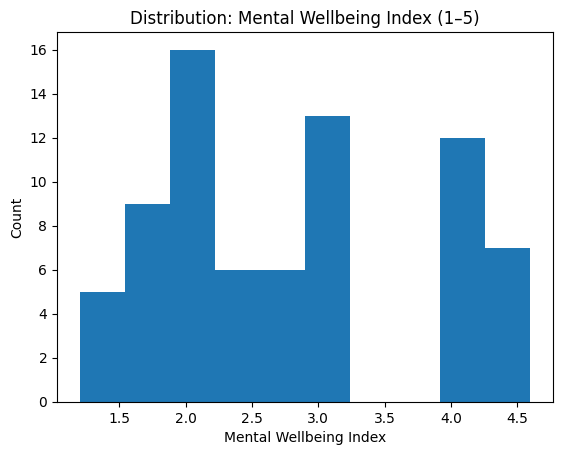

In [9]:
plt.figure()
vals = df["Mental_Wellbeing_Index"].dropna()
plt.hist(vals, bins=10)
plt.title("Distribution: Mental Wellbeing Index (1–5)")
plt.xlabel("Mental Wellbeing Index")
plt.ylabel("Count")
plt.show()


## 9. Mental Well-Being by Weekly Work Hours

Work hours are a central feature of Singapore’s professional culture.

Here, we compare average mental well-being across work-hour brackets to assess whether longer hours are associated with lower sustainability.


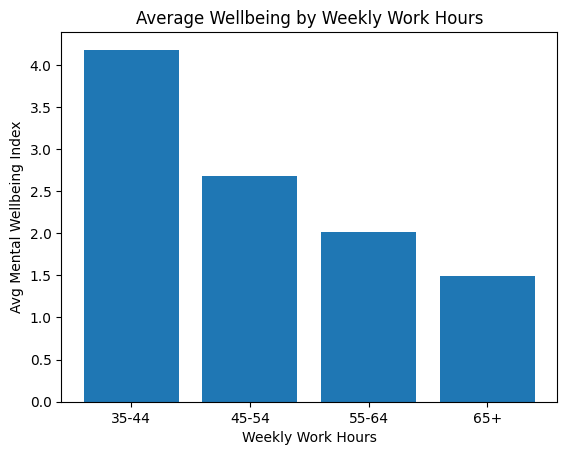

In [10]:
if "Weekly_Work_Hours" in df.columns:
    grp = df.groupby("Weekly_Work_Hours")["Mental_Wellbeing_Index"].agg(["mean","count"]).reset_index()
    # stable ordering
    order = ["< 35","35-44","45-54","55-64","65+"]
    grp["Weekly_Work_Hours"] = pd.Categorical(grp["Weekly_Work_Hours"], categories=order, ordered=True)
    grp = grp.sort_values("Weekly_Work_Hours")

    plt.figure()
    plt.bar(grp["Weekly_Work_Hours"], grp["mean"])
    plt.title("Average Wellbeing by Weekly Work Hours")
    plt.xlabel("Weekly Work Hours")
    plt.ylabel("Avg Mental Wellbeing Index")
    plt.show()

    grp


## 10. Relationship Between Work Pressure and Well-Being

We examine the association between the Work Pressure Index and the Mental Well-Being Index using a scatter plot and correlation.

This provides an initial, unadjusted look at how pressure relates to well-being.


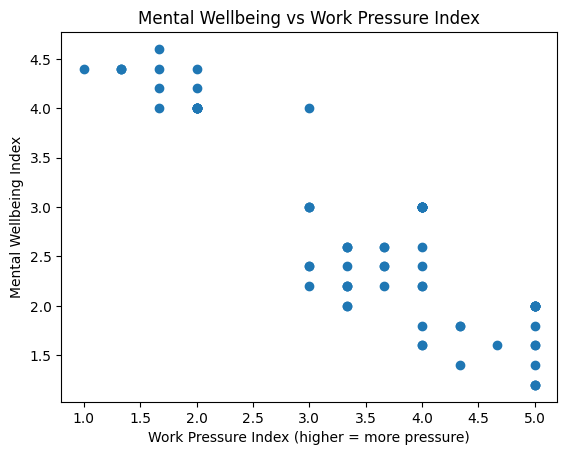

Correlation: -0.8842877927303624


In [11]:
plt.figure()
x = df["Work_Pressure_Index"]
y = df["Mental_Wellbeing_Index"]
mask = x.notna() & y.notna()
plt.scatter(x[mask], y[mask])
plt.title("Mental Wellbeing vs Work Pressure Index")
plt.xlabel("Work Pressure Index (higher = more pressure)")
plt.ylabel("Mental Wellbeing Index")
plt.show()

if mask.sum() > 2:
    print("Correlation:", np.corrcoef(x[mask], y[mask])[0,1])


## 11. Industry-Level Differences

Different industries may exhibit distinct cultures around pressure, boundaries, and recovery.

This comparison highlights which sectors appear more or less sustainable on average.


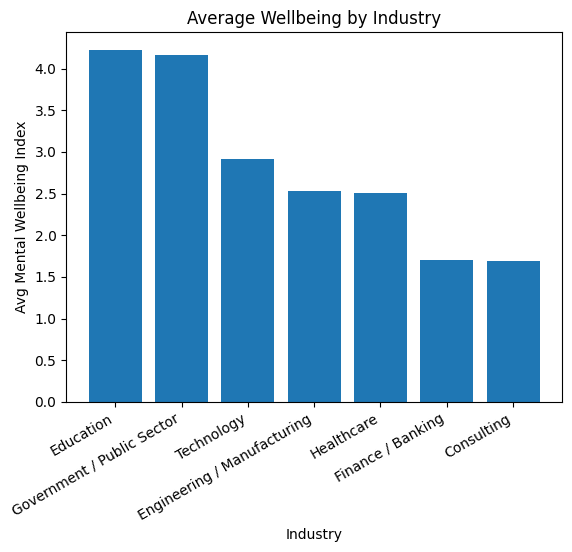

In [12]:
if "Industry" in df.columns:
    grp = df.groupby("Industry")["Mental_Wellbeing_Index"].agg(["mean","count"]).reset_index()
    grp = grp.sort_values("mean", ascending=False)

    plt.figure()
    plt.bar(grp["Industry"], grp["mean"])
    plt.title("Average Wellbeing by Industry")
    plt.xlabel("Industry")
    plt.ylabel("Avg Mental Wellbeing Index")
    plt.xticks(rotation=30, ha="right")
    plt.show()

    grp


## 12. Multivariate Regression: Adjusted Associations

To move beyond bivariate relationships, we estimate an OLS regression with:
- Numeric predictors (hours, commute, sleep, pressure)
- Categorical controls (industry, employment status, age group)

This allows us to examine **adjusted associations** with mental well-being while holding other factors constant.


In [14]:
import statsmodels.api as sm
import numpy as np
import pandas as pd

predictors_num = [c for c in [
    "Weekly_Work_Hours_Num",
    "Commute_OneWay_Min",
    "Sleep_WorkNights_Hrs",
    "Work_Pressure_Index"
] if c in df.columns]

predictors_cat = [c for c in ["Industry", "Employment_Status", "Age_Group"] if c in df.columns]

model_df = df[["Mental_Wellbeing_Index"] + predictors_num + predictors_cat].copy()

# Force numeric predictors to truly be numeric
for c in predictors_num:
    model_df[c] = pd.to_numeric(model_df[c], errors="coerce")

# Drop missing rows (clean model input)
model_df = model_df.dropna()

# One-hot encode categoricals
X = pd.get_dummies(model_df[predictors_num + predictors_cat], drop_first=True)

# Convert EVERYTHING in X to numeric + float (kills the object dtype issue)
X = X.apply(pd.to_numeric, errors="coerce").astype(float)

y = model_df["Mental_Wellbeing_Index"].astype(float)

X = sm.add_constant(X)

# Fit
ols = sm.OLS(y, X).fit()
print(ols.summary())


                              OLS Regression Results                              
Dep. Variable:     Mental_Wellbeing_Index   R-squared:                       0.857
Model:                                OLS   Adj. R-squared:                  0.429
Method:                     Least Squares   F-statistic:                     2.000
Date:                    Mon, 19 Jan 2026   Prob (F-statistic):              0.370
Time:                            03:02:45   Log-Likelihood:                 8.4828
No. Observations:                       9   AIC:                            -2.966
Df Residuals:                           2   BIC:                            -1.585
Df Model:                               6                                         
Covariance Type:                nonrobust                                         
                                          coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------

## 13. Bootstrap Inference: Low vs High Work Hours

To quantify uncertainty and avoid over-reliance on parametric assumptions, we use bootstrap resampling.

We estimate a confidence interval for the difference in well-being between low-hour and high-hour groups.


In [15]:
def bootstrap_diff(a, b, n_boot=5000, seed=42):
    rng = np.random.default_rng(seed)
    a = np.array(a); b = np.array(b)
    diffs = []
    for _ in range(n_boot):
        a_s = rng.choice(a, size=len(a), replace=True)
        b_s = rng.choice(b, size=len(b), replace=True)
        diffs.append(np.mean(a_s) - np.mean(b_s))
    diffs = np.array(diffs)
    ci = np.quantile(diffs, [0.025, 0.975])
    return diffs.mean(), ci

if "Weekly_Work_Hours" in df.columns:
    low = df.loc[df["Weekly_Work_Hours"].isin(["< 35","35-44"]), "Mental_Wellbeing_Index"].dropna()
    high = df.loc[df["Weekly_Work_Hours"].isin(["55-64","65+"]), "Mental_Wellbeing_Index"].dropna()

    if len(low) >= 5 and len(high) >= 5:
        diff, (lo, hi) = bootstrap_diff(low, high)
        print("Mean difference (LowHours - HighHours):", round(diff,3))
        print("95% bootstrap CI:", (round(lo,3), round(hi,3)))
    else:
        print("Not enough data in low/high hour groups for bootstrap CI.")


Mean difference (LowHours - HighHours): 2.337
95% bootstrap CI: (np.float64(2.17), np.float64(2.5))


## 14. Predictive Modeling: Identifying Low Well-Being Risk

We frame well-being as a binary outcome (below vs above median) and evaluate a logistic regression model using cross-validated ROC-AUC.

This assesses whether work-related features contain predictive signal for identifying individuals at risk of low well-being.


In [16]:
from sklearn.model_selection import StratifiedKFold, cross_val_score
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression

df_ml = df[df["Mental_Wellbeing_Index"].notna()].copy()
median_wb = df_ml["Mental_Wellbeing_Index"].median()
df_ml["Low_Wellbeing"] = (df_ml["Mental_Wellbeing_Index"] < median_wb).astype(int)

num_features = [c for c in predictors_num if c in df_ml.columns]
cat_features = [c for c in predictors_cat if c in df_ml.columns]

X = df_ml[num_features + cat_features]
y = df_ml["Low_Wellbeing"]

numeric_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median"))
])

categorical_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(handle_unknown="ignore"))
])

preprocess = ColumnTransformer(
    transformers=[
        ("num", numeric_transformer, num_features),
        ("cat", categorical_transformer, cat_features),
    ]
)

clf = Pipeline(steps=[
    ("preprocess", preprocess),
    ("model", LogisticRegression(max_iter=2000))
])

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
auc_scores = cross_val_score(clf, X, y, cv=cv, scoring="roc_auc")

print("5-fold CV ROC-AUC:", auc_scores)
print("Mean AUC:", round(auc_scores.mean(),3), "Std:", round(auc_scores.std(),3))


5-fold CV ROC-AUC: [0.96428571 0.82142857 0.96428571 0.89285714 0.89795918]
Mean AUC: 0.908 Std: 0.053


In [18]:
OUT_XLSX = "/content/singapore_wellbeing_cleaned.xlsx"
df.to_excel(OUT_XLSX, index=False)
print("Saved cleaned dataset:", OUT_XLSX)


Saved cleaned dataset: /content/singapore_wellbeing_cleaned.xlsx


Work_Pressure_Index → Exhaustion → Mental_Wellbeing_Index


## 15. Mediation Analysis: Does Exhaustion Explain the Pressure–Well-Being Link?

Correlation alone does not explain *how* pressure affects well-being.

We test a mediation hypothesis:
- Work pressure increases exhaustion
- Exhaustion, in turn, reduces mental well-being

This helps identify **mechanisms**, not just associations.


In [19]:
# Step 1: Work pressure → Wellbeing
X1 = sm.add_constant(df[["Work_Pressure_Index"]].dropna())
y1 = df.loc[X1.index, "Mental_Wellbeing_Index"]
m1 = sm.OLS(y1, X1).fit()

# Step 2: Work pressure → Exhaustion
X2 = sm.add_constant(df[["Work_Pressure_Index"]].dropna())
y2 = df.loc[X2.index, "Exhaustion_Score"]
m2 = sm.OLS(y2, X2).fit()

# Step 3: Work pressure + Exhaustion → Wellbeing
X3 = sm.add_constant(df[["Work_Pressure_Index", "Exhaustion_Score"]].dropna())
y3 = df.loc[X3.index, "Mental_Wellbeing_Index"]
m3 = sm.OLS(y3, X3).fit()

print("Model 1: Pressure → Wellbeing")
print(m1.summary())

print("\nModel 2: Pressure → Exhaustion")
print(m2.summary())

print("\nModel 3: Pressure + Exhaustion → Wellbeing")
print(m3.summary())


Model 1: Pressure → Wellbeing
                              OLS Regression Results                              
Dep. Variable:     Mental_Wellbeing_Index   R-squared:                       0.782
Model:                                OLS   Adj. R-squared:                  0.779
Method:                     Least Squares   F-statistic:                     258.2
Date:                    Mon, 19 Jan 2026   Prob (F-statistic):           1.62e-25
Time:                            03:07:11   Log-Likelihood:                -46.339
No. Observations:                      74   AIC:                             96.68
Df Residuals:                          72   BIC:                             101.3
Df Model:                               1                                         
Covariance Type:                nonrobust                                         
                          coef    std err          t      P>|t|      [0.025      0.975]
----------------------------------------------------

## 16. Quantile Regression: Who Is Most Affected?

Average effects can hide important heterogeneity.

Using quantile regression, we examine whether work pressure has a stronger effect:
- Among individuals with already low well-being
- Compared to those at the median or higher end of the distribution


In [20]:
from statsmodels.regression.quantile_regression import QuantReg

quantiles = [0.25, 0.5, 0.75]

for q in quantiles:
    qr = QuantReg(
        df["Mental_Wellbeing_Index"],
        sm.add_constant(df[["Work_Pressure_Index"]])
    ).fit(q=q)
    print(f"\nQuantile {q}")
    print(qr.summary())



Quantile 0.25
                           QuantReg Regression Results                            
Dep. Variable:     Mental_Wellbeing_Index   Pseudo R-squared:               0.4642
Model:                           QuantReg   Bandwidth:                      0.5495
Method:                     Least Squares   Sparsity:                        1.445
Date:                    Mon, 19 Jan 2026   No. Observations:                   74
Time:                            03:07:23   Df Residuals:                       72
                                            Df Model:                            1
                          coef    std err          t      P>|t|      [0.025      0.975]
---------------------------------------------------------------------------------------
const                   5.4000      0.216     25.025      0.000       4.970       5.830
Work_Pressure_Index    -0.8400      0.058    -14.395      0.000      -0.956      -0.724

Quantile 0.5
                           QuantReg Re

## 17. Model Interpretability: Feature Importance

To improve interpretability of the predictive model, we examine coefficient magnitudes.

This highlights which features contribute most strongly to identifying low well-being risk.


In [21]:
# Feature importance from logistic regression
clf.fit(X, y)

feature_names = clf.named_steps["preprocess"].get_feature_names_out()
coefs = clf.named_steps["model"].coef_[0]

importance = pd.DataFrame({
    "feature": feature_names,
    "coef": coefs,
    "abs_coef": np.abs(coefs)
}).sort_values("abs_coef", ascending=False)

importance.head(10)


,feature,coef,abs_coef
15,cat__Age_Group_31-35,-0.594160,0.594160
13,cat__Age_Group_23-26,0.448690,0.448690
0,num__Weekly_Work_Hours_Num,0.404794,0.404794
9,cat__Industry_Healthcare,-0.294109,0.294109
3,num__Work_Pressure_Index,-0.282871,0.282871
12,cat__Employment_Status_Student + working,0.270612,0.270612
11,cat__Employment_Status_Full-time,-0.270509,0.270509
7,cat__Industry_Finance / Banking,0.261284,0.261284
4,cat__Industry_Consulting,0.253252,0.253252
14,cat__Age_Group_27-30,0.145573,0.145573


## 18. Key Takeaways and Social Good Implications

### Summary
- Work pressure is strongly associated with lower mental well-being
- Long hours and limited recovery compound this effect
- Exhaustion appears to partially mediate the pressure–well-being relationship
- Pressure effects are strongest among those already struggling

### Implications
- Sustainable work policies should prioritize recovery, not just productivity
- Reducing after-hours expectations may yield disproportionate well-being benefits
- Targeted interventions are needed for high-pressure industries

### Limitations
- Self-reported measures
- Cross-sectional design limits causal inference

### Next Steps
- Extend mediation with longitudinal data
- Evaluate policy interventions experimentally